In [4443]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta

In [4444]:
ticker='BTC-USD'
date="2025-05-30"
end="2025-09-30"
df=yf.download(ticker,start=date,end=end)
df.columns=[i[0] for i in df.columns]
df['Pct_Change']=df['Open'].pct_change()
df.dropna(inplace=True)
df['adj']=((df['Close']+df['Open'])/2)
df

C:\Users\user\AppData\Local\Temp\ipykernel_5324\3137608794.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,start=date,end=end)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume,Pct_Change,adj
Date,,,,,,,
2025-05-31,104638.093750,104927.101562,103136.117188,103994.718750,38997843858,-0.015632,104316.406250
2025-06-01,105652.101562,105884.546875,103826.953125,104637.296875,37397056873,0.006179,105144.699219
2025-06-02,105881.531250,105958.312500,103727.546875,105649.812500,45819706290,0.009676,105765.671875
2025-06-03,105432.468750,106813.578125,104920.843750,105888.476562,46196508367,0.002259,105660.472656
2025-06-04,104731.984375,105997.695312,104232.703125,105434.367188,44544857105,-0.004289,105083.175781
...,...,...,...,...,...,...,...
2025-09-04,110723.601562,112208.328125,109347.226562,111718.148438,60131132901,0.004744,111220.875000
2025-09-05,110650.984375,113357.492188,110233.398438,110723.015625,60241647677,-0.008908,110687.000000
2025-09-06,110224.695312,111275.015625,110024.085938,110650.570312,21500719036,-0.000654,110437.632812


In [4445]:
last_date = df.index[-1]
new_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=1,freq="1d")
new_rows = pd.DataFrame({
    "Open": [0]*1,
    "High": [0]*1,
    "Low": [0]*1,
    "Close": [0]*1,
    'Pct_Change':[0]*1,
    'adj':[0]*1,
    "Volume": [0]*1,
    "Date": new_dates
})
new_rows = new_rows.astype(df.reset_index().dtypes.to_dict())
df = pd.concat([df.reset_index(),new_rows], ignore_index=True)
df = df.set_index("Date")
x=[df['Close'].tail(2).values[0]]*1
df.loc[df.index[-2:], "Close"]=df['Open'].tail(2).tolist()
df.loc[df.index[-1:], "Close"]=x
df

,Close,High,Low,Open,Volume,Pct_Change,adj
Date,,,,,,,
2025-05-31,104638.093750,104927.101562,103136.117188,103994.718750,38997843858,-0.015632,104316.406250
2025-06-01,105652.101562,105884.546875,103826.953125,104637.296875,37397056873,0.006179,105144.699219
2025-06-02,105881.531250,105958.312500,103727.546875,105649.812500,45819706290,0.009676,105765.671875
2025-06-03,105432.468750,106813.578125,104920.843750,105888.476562,46196508367,0.002259,105660.472656
2025-06-04,104731.984375,105997.695312,104232.703125,105434.367188,44544857105,-0.004289,105083.175781
...,...,...,...,...,...,...,...
2025-09-05,110650.984375,113357.492188,110233.398438,110723.015625,60241647677,-0.008908,110687.000000
2025-09-06,110224.695312,111275.015625,110024.085938,110650.570312,21500719036,-0.000654,110437.632812
2025-09-07,111167.617188,111591.078125,110211.625000,110221.328125,24618007520,-0.003879,110694.472656


In [4446]:
def flexible_rsi(series):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(window=8,center=True).mean()
    roll_down = down.rolling(window=8,center=True).mean()
    rs = roll_up / roll_down
    rsi = 100 - (100 / (1 + rs))
    rsi_scaled = (100 - (100 / (1 + rs)))/100
    return rsi_scaled
# Example usage
prices =df.Close
rsi_flex = flexible_rsi(prices)
df['Positions']=rsi_flex.shift(2)

In [4447]:
df['Pct_Change']=df['Close'].pct_change()
df.tail(6)

,Close,High,Low,Open,Volume,Pct_Change,adj,Positions
Date,,,,,,,,
2025-09-04,110723.601562,112208.328125,109347.226562,111718.148438,60131132901,-0.008947,111220.875000,0.401989
2025-09-05,110650.984375,113357.492188,110233.398438,110723.015625,60241647677,-0.000656,110687.000000,0.652333
2025-09-06,110224.695312,111275.015625,110024.085938,110650.570312,21500719036,-0.003853,110437.632812,0.681523
2025-09-07,111167.617188,111591.078125,110211.625000,110221.328125,24618007520,0.008555,110694.472656,0.744044
2025-09-08,111142.382812,112849.140625,110693.453125,111142.382812,40102977536,-0.000227,111674.101562,0.746157
2025-09-09,112205.820312,0.000000,0.000000,0.000000,0,0.009568,0.000000,NaN


<Axes: xlabel='Date'>

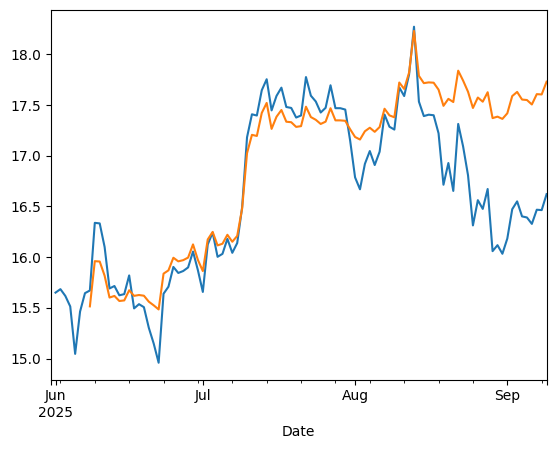

In [4448]:
(15.5*(1+df['Pct_Change']).cumprod()).plot()
(15.5*(1+((df['Positions'].shift(1))*df['Pct_Change'])).cumprod()).plot()

In [4449]:
df['Positions'].std()#-6---+.tail(50).plot()

np.float64(0.19592736906444977)

<Axes: xlabel='Date'>

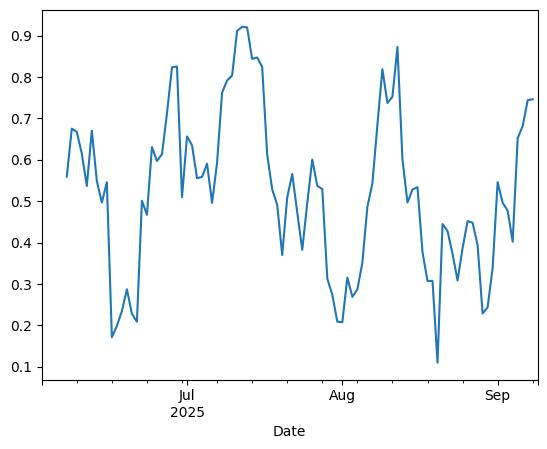

In [4450]:
df['Positions'].tail(100).plot()